# Implement a Metropolis-Hasting Sampler

Do you remember it? it is a MCMC sampler and it is quite simple in logic.


Here is the algorithm (or you can check it from [doi:10.1093/mnras/stt2190](https://academic.oup.com/mnras/article/437/4/3918/1011939)):

1. Choose $\boldsymbol{x}_0 \in \Omega_\boldsymbol{\theta}$
2. For each step ($\boldsymbol{x}_i$) propose $\boldsymbol{x}_\text{trial}$ drawn from a symmetric distribution $q(\boldsymbol{x}_\text{trial}|\boldsymbol{x}_i)$ (a gaussian??)
3. Compute $k \equiv \text{min}[1, p(\boldsymbol{x}_\text{trial})/p(\boldsymbol{x}_i)]$ the new value is given by
    * $\boldsymbol{x}_{i+1} = \boldsymbol{x}_i$ with probability $(1-k)$
    * $\boldsymbol{x}_{i+1} = \boldsymbol{x}_\text{trial}$ with probability $k$
4. Iterate from (2) *until convergence*

# Material that we need

First of all the libraries:

In [1]:
import numpy
import random
from matplotlib import pyplot as plt

In [2]:
rng = numpy.random.default_rng(seed=666)

## Bayes Theorem:

Let me refresh you on this: an MCMC sampler uses the likelihood to sample the parameter space in search for a representation of the posterior:

$$P(\boldsymbol{\theta}|\boldsymbol{D}) \propto P(\boldsymbol{\theta}) \cdot \mathcal{L}_\boldsymbol{D}(\boldsymbol{\theta})$$ 

i.e. we drop the evidence as the intent is to move **walkers** around the parameter space and have a measure to test whether a new position is more likely than another.

If you remember from the statistics course, we do not use the likelihood directly but its logarithm (because it is more stable and because reasons).

But before looking on that, let's generate a dataset:

In [3]:
# Choose the "true" parameters.
m_true = -0.9594
b_true = 4.294
f_true = 0.534

In [4]:
# Generate some synthetic data from the model.
N = 50
xobs = numpy.sort(10 * rng.normal(size=N))
yerr = 0.1 + .5 * rng.normal(size=N)
yobs = m_true * xobs + b_true
yobs += numpy.abs(f_true * yobs) * rng.standard_normal(size=N)
yobs += yerr * rng.standard_normal(size=N)
yerr = numpy.abs(yerr)

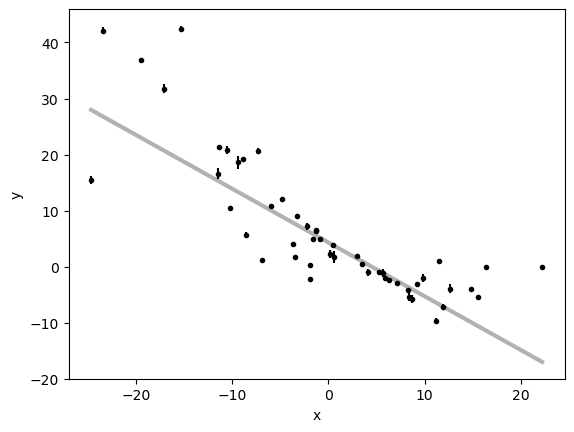

In [5]:
fig, ax = plt.subplots(1,1)

_ = ax.errorbar(xobs, yobs, yerr=yerr, fmt=".k", capsize=0)
x0 = numpy.linspace(xobs.min(), xobs.max(), 500)
_ = ax.plot(x0, m_true * x0 + b_true, "k", alpha=0.3, lw=3)
_ = ax.set(xlabel='x', ylabel='y')

## LogLikelihood and Prior

I feel particularly kind today therefore you will not have to implement the log-likelihood and log-prior yourself, do not get used to it.

In [6]:
def log_likelihood(theta, xx, yy, ee):
    m, b, log_f = theta
    model = m * xx + b
    sigma2 = ee**2 + model**2 * numpy.exp(2 * log_f)
    return -0.5 * numpy.sum((yy - model) ** 2 / sigma2 + numpy.log(sigma2))

In [7]:
prior = [
    [-2.0,0.0],
    [2.0,6.0],
    [-4.0, 4.0]
]

In [8]:
def log_prior(theta, prior):
    m, b, log_f = theta
    mlim, blim, flim = prior
    if mlim[0] < m < mlim[1] and blim[0] < b < blim[1] and flim[0] < log_f < flim[1]:
        return 0.0
    return -numpy.inf

In [9]:
def log_probability(theta, xx, yy, ee, prior):
    lp = log_prior(theta, prior)
    if not numpy.isfinite(lp):
        return -numpy.inf
    return lp + log_likelihood(theta, xx, yy, ee)

## The actual assignment

I want you to implement the algorithm detailed at the beginning of this notebook. Desiderata:

* I would like to have a class which implements the sampler, stores the positions visited by the walkers and whether a position has been accepted or not.
* The class should implement the best practices we have seen in class (e.g. implement a `__str__` dunder method for printing)
* the class should be documented
* the first thing an class instance method should do is to check whether the attributes that have been passed by the user (you are the user in this case) have the correct properties (raise an `AttributeError` if not)

**Hints:**
* **test** **test** **test** **test** **test** **test** every step, you are in a jupyter notebook, open a new cell and test each functionality before inserting it into the class implementation
* I have provided at the end the code snippet to plot the marginalized posterior, nonetheless, I can already tell you that it should be gaussian (as the dataset is gaussian), thus the **mean** and **standard deviation** are good estimators of the posterior.
* you can try to implement it with **a single walker for starting**, doing it with multiple workers can be an extension

**Bonus:**
* If you feel particularly productive, also wrap everything into a module or a package.

**The algorithm again here**
[doi:10.1093/mnras/stt2190](https://academic.oup.com/mnras/article/437/4/3918/1011939):

1. Choose $\boldsymbol{x}_0 \in \Omega_\boldsymbol{\theta}$
2. For each step ($\boldsymbol{x}_i$) propose $\boldsymbol{x}_\text{trial}$ drawn from a symmetric distribution $q(\boldsymbol{x}_\text{trial}|\boldsymbol{x}_i)$ (a gaussian??)
3. Compute $k \equiv \text{min}[1, p(\boldsymbol{x}_\text{trial})/p(\boldsymbol{x}_i)]$ the new value is given by
    * $\boldsymbol{x}_{i+1} = \boldsymbol{x}_i$ with probability $(1-k)$
    * $\boldsymbol{x}_{i+1} = \boldsymbol{x}_\text{trial}$ with probability $k$
4. Iterate from (2) *until convergence*

In [252]:
class MHsampler () :
    

    def __init__ ( self, nwalkers, logprob, lp_args:"sans prior", prior, obs, step=0.05 ) :
        self.nwalkers = nwalkers
        self.logprob = logprob
        self.ndim = len(prior)
        self.prior = prior
        self.step = step
        self.obs = obs
        self.has_been_tempered = False
        pass

    def run ( self, nsteps, pstart=None, verbose=False, initial_temperature=1) :
        # make the data array
        data = numpy.zeros((self.nwalkers, nsteps, self.ndim+2))
        
        # my chains keep getting stuck away from the true values
        # I could increase my step size until it impacts my final contours
        # but instead I'll add in a temperature system to flatten my logprob
        # this temperature will approach 1 (no tempering) by halfway through your nsteps for now
        # otherwise, the shape is arbitrary
        # I would prefer to allow the user to define a temp function, but this is what I've allowed myself the time to do
        
        # PS: This didn't end up helping and I dont want to try and figure out why
        if not initial_temperature==1:
            print("Proceed with caution, the tempering function probably doesn't work correctly!")
            self.has_been_tempered = True
            x = numpy.array(range(nsteps))
            x = x/nsteps
            temp_func = 0.5*initial_temperature*((numpy.arctan(-100*(x-0.25))/(numpy.pi/2))+1)
            if verbose:
                plt.plot(x, temp_func)
        else: 
            temp_func = numpy.ones(nsteps)
        # fill the initial positions of the walkers
        if pstart == None:
            data = self.generate_start_point(data)
        else:
            print(pstart)
            for i, d in enumerate(data):
                d[0][2:] = pstart[i]
                
                d[0][0:2] = [1, self.logprob( pstart[i], *self.obs, prior )]
        
        # now start walking
        for i in range(nsteps-1):
            for j in range(self.nwalkers):
                x_trial = self.find_step(data[j][i][2:])
                lp_trial = self.logprob( x_trial, *self.obs, prior )
                
                k = numpy.min([1, numpy.exp((lp_trial - data[j][i][1]))/temp_func[i]])
                if numpy.isnan(k):
                    k = 0
                full_trial = numpy.array([1, lp_trial])
                full_trial = numpy.append(full_trial, x_trial)
                options = [numpy.append([0], data[j][i][1:]), full_trial]
                data[j][i+1] = options[numpy.random.binomial(1, k)]
        self.data = data
        print("Done!")
        return data
    
    def find_step( self, x_last) :
        x_next = x_last + self.step*numpy.random.randn(self.ndim)
        return x_next
    
    def generate_start_point(self, data):
        for i in range(self.nwalkers):
            for j in range(self.ndim):
                data[i][0][j+2] += [numpy.random.uniform(low=prior[j][0], high=prior[j][1])]
            data[i][0][0:2] = [1, self.logprob( tuple(data[i][0][2:]), *self.obs, prior )]
        return data
        

    def acceptance_fraction ( self ) :
        print(len(self.data[0]))
        return self.data[:, :, 0].sum(axis=1)/len(self.data[0])
    
    def get_flat_chain ( self, burnin_frac = 0 ) :
        if burnin_frac < 0.5 and self.has_been_tempered:
            print("This chain has been tempered, use a burnin >= 0.5")
            return 0
        data = self.data
        flat_chain = numpy.zeros((2, self.ndim))
        burnin_index = int(burnin_frac*len(data[0]))
        for i, d in enumerate(data):
            flat_chain = numpy.append(flat_chain, d[burnin_index:,2:], axis=0)
        return flat_chain[2:]

In [259]:
sampler = MHsampler(20, log_probability, (), prior, 
                    (xobs, yobs, yerr), step=0.05)
chains = sampler.run(10000)
print(sampler.acceptance_fraction())

/tmp/ipykernel_5417/3117529227.py:70: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  data[i][0][j+2] += [numpy.random.uniform(low=prior[j][0], high=prior[j][1])]
/tmp/ipykernel_5417/3117529227.py:50: RuntimeWarning: overflow encountered in exp
  k = numpy.min([1, numpy.exp((lp_trial - data[j][i][1]))/temp_func[i]])


Done!
10000
[0.582  0.6017 0.6073 0.6002 0.6014 0.5877 0.1216 0.5887 0.5904 0.5939
 0.6029 0.583  0.5887 0.5801 0.6145 0.2036 0.5949 0.597  0.6002 0.5939]


In [262]:
outchain = sampler.get_flat_chain(0.5)

I guess that then we will have to instantiate this object:

```python
sampler = MHsampler( nwalkers=1, logprob=log_probability, ndim=3, "what goes here?" )
```

and after having a working istance, we will need to run the sampling:

```python
sampler.run( 100000, pstart="what goes here?" )
```

## Test test test!!

In [239]:
import corner

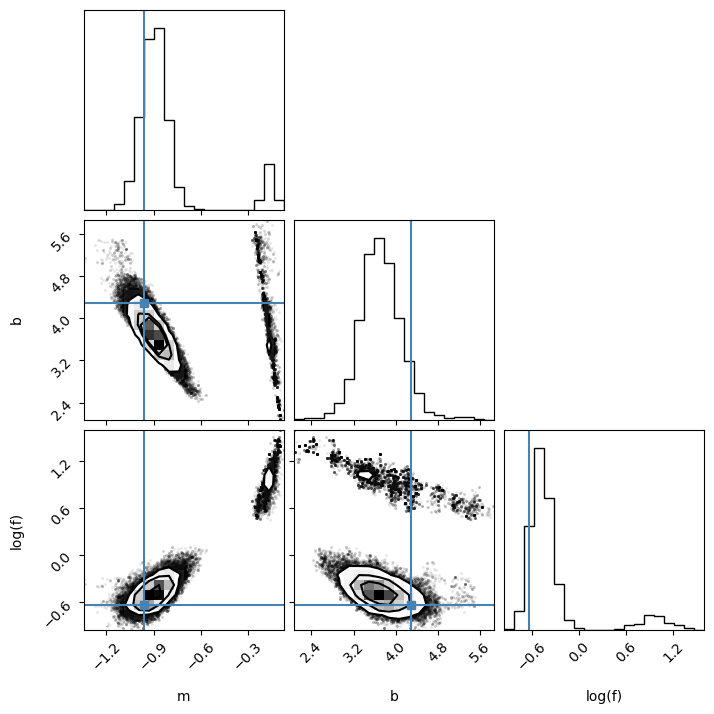

In [263]:
fig = corner.corner(
    outchain, labels = ["m", "b", "log(f)"], truths = [m_true, b_true, numpy.log(f_true)]
)

* and when implementation testing is finished, the final test is to check whether or not it worked:
```python
outchain = sampler.get_flat_chain(burnin=1000)
import corner
fig = corner.corner(
    outchain, labels = ["m", "b", "log(f)"], truths = [m_true, b_true, numpy.log(f_true)]
)
```
![](posterior.png)